Test JaxTracer on Hydro Turbulence

Import Libs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

#add path
sys.path.insert(0, '../')     # import path/to/sloth

import src.core.config as config
config.jax_init(force_device = "gpu", enable_x64= True)

import core.beam as beam_initialiser
import core.domain as d
import core.propagator as p
import processing.diagnostics as diag

import utils.handle_filetypes as utilIO
import jax.numpy as jnp

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /rds/general/user/sm13118/home/dev/SLOTH/src

Disabling python multi-threading...
Initialising jax...


Default jax backend: gpu
Available devices: [CudaDevice(id=0)]


<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/SLOTH/src/processing/diagnostics.py'>

Import domain

In [2]:
base_folder = "/rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC"
path_to_file = "/xyz12_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0203"
filename = base_folder+path_to_file
#  -----------------

#load hdf
ne, dims, spacing = utilIO.hdf_readin(filename, prefer_ye=True, force_override=True, verbose=True)

print(ne.shape)

'''
# multiply domain to match real size experimental target
multi_x = 0 # get multiplier x
multi_y = 0 # get multiplier y
multi_z = 0 # get multiplier z

for i in range(multi_x):
    ne = np.append(ne, ne, axis = 0)
for j in range(multi_y):
    ne = np.append(ne, ne, axis = 1)
for k in range(multi_z):
    ne = np.append(ne, ne, axis = 2)
'''

dims = ne.shape

extent_x = ((dims[0]*spacing[0].v)/2) * 1e-2
extent_y = ((dims[1]*spacing[1].v)/2) * 1e-2
extent_z = ((dims[2]*spacing[2].v)/2) * 1e-2

lengths = 2 * jnp.array([extent_x, extent_y, extent_z], dtype = jnp.float32)
print(lengths)

ne_x = np.linspace(-extent_x,extent_x, dims[0])
ne_y = np.linspace(-extent_y,extent_y, dims[1])
ne_z = np.linspace(-extent_z,extent_z, dims[2])

print(f'extent x: {extent_x}')
print(f'extent y: {extent_y}')
print(f'extent z: {extent_z}')

print(f'dims x: {dims[0]}')
print(f'dims y: {dims[1]}')
print(f'dims z: {dims[2]}')

print("\n\n")

# is this baseline not decreasing after each run? - testing manually deleting objects first
# baseline = memory_report()['used_raw']
probing_direction = 'z'

Np = 5e6

# del ne_x
# del ne_y
# del ne_z
# del ne

yt : [INFO     ] 2026-03-06 21:08:35,224 Parameters: current_time              = 1.8049559705796948e-07
yt : [INFO     ] 2026-03-06 21:08:35,225 Parameters: domain_dimensions         = [1200  750  500]
yt : [INFO     ] 2026-03-06 21:08:35,225 Parameters: domain_left_edge          = [-0.1  0.   0. ]
yt : [INFO     ] 2026-03-06 21:08:35,226 Parameters: domain_right_edge         = [1.1  0.75 0.5 ]
yt : [INFO     ] 2026-03-06 21:08:35,226 Parameters: cosmological_simulation   = 0


[hdf_readin] Loaded: /rds/general/user/sm13118/projects/afosrturbulence/live/sm13118/sim/FLASH_4.8/Archive/RadMeshAblation/1200x750x500-double-CH-3rd-HLLC/xyz12_prp_CH_100pts_double_mesh_ug_3rd_5x100_10x75_12x100_cfl_0.5_8eV/radmeshablation_3d_prp_CH_ug_3rd_hdf5_plt_cnt_0203
[hdf_readin] has_ye=True (prefer_ye=True)
[hdf_readin] max_level=0
[hdf_readin] dims=(1200, 750, 500)
[hdf_readin] spacing=[unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length'), unyt_quantity(0.001, 'code_length')]
(1200, 750, 500)
[0.012  0.0075 0.005 ]
extent x: 0.006000000000000001
extent y: 0.00375
extent z: 0.0025
dims x: 1200
dims y: 750
dims z: 500





In [3]:
domain = d.ScalarDomain(lengths, dims, leeway_factor = 3, ne_type = "import", probing_direction = probing_direction, Np = Np, ne = ne.v*1e6)

Predicted size in memory of domain: 1.6763806343078613 GB

Memory prior to domain creation:
 - total : 44.98828125 GB
 - free  : 44.149658203125 GB
 - used  : 858.75 MB

Est. ray size in memory: 10.281801223754883 GB
Est. domain memory limit: 10.058283805847168 GB
 --> inc. +200.0% variance margin
Total estimated maximum: 40.903687477111816 GB

padded up-to 1200 entries.(1200, 750, 500) --> 
 --> x padded with: 0 nan's
 --> y padded with: 450 nan's
 --> z padded with: 700 nan's

Using imported ne domain. Be careful that your import matches with other passed variables, this is not sanity checked by the init function.


Tracing using JaxTracer

1.1398088520197473e+27


np.float64(0.0025)

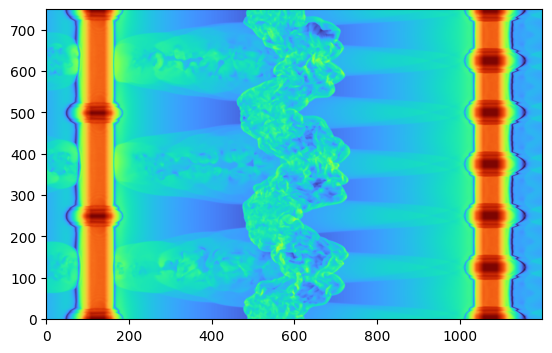

In [4]:
print(domain.ne.T.max())
plt.imshow(domain.ne[:,:,20].T, origin="lower",cmap='turbo', norm="log")
extent_z

In [5]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"

rf_jax, _, duration = p.solve((beam_size, divergence, ne_extent, probing_direction, beam_type, False), domain, probing_extent, verbose = False)


Number of domain batches: 1
Number of ray batches: 1

Using tuple values to create the unbatched beam, domain must be used in the same fashion.

Est. size in memory of rays (1 = 736 B): 3.427267074584961 GB
 --> Np = 5000000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.0025 mm's to the target depth of 0.0025 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.00037097930908203125 secondsTrue
True
True

Completed ray trace in 402.376 seconds.


### Inspects Histograms - Shadow and Refractogram

Text(0, 0.5, '$\\phi$ (mrad)')

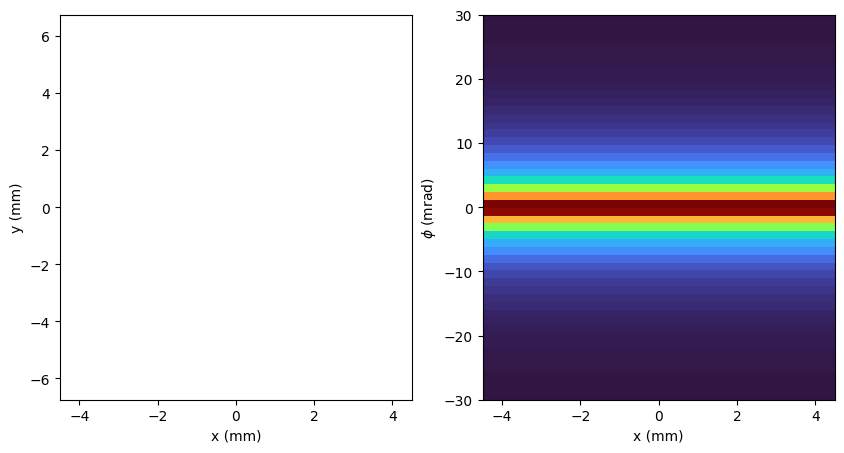

In [6]:
import matplotlib.colors as mcolors

nbins_x=3448
nbins_y=2574


rf_np = np.asarray(rf_jax)
# ----------------------

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))

_,_,_,img1 = ax2.hist2d(rf_np[0]*1e3, rf_np[2]*1e3, bins=(nbins_x, nbins_y), cmap ="turbo", norm=mcolors.PowerNorm(1));

ax1.set_ylim([-6.75, 6.75])
ax1.set_xlim(-4.5, 4.5)
ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_aspect('auto')

ax1.set_xlabel(r"x (mm)")
ax1.grid(False)
ax1.set_ylabel(r"y (mm)")

_,_,_,img1 = ax2.hist2d(rf_np[0]*1e3, rf_np[3]*1e3, bins=(nbins_x, nbins_y), norm=mcolors.PowerNorm(1), cmap ="turbo");

ax2.set_xlim(-4.5, 4.5)
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_aspect('auto')

ax2.set_xlabel(r"x (mm)")
ax2.set_ylim(-30,30)
ax2.set_yticks([-30, -20,-10,0,10,20,30])
ax2.grid(False)
ax2.set_ylabel(r"$\phi$ (mrad)")

In [19]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(rf_jax, focal_plane = -35, prefilter_input = True)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 10, clear_mem = False)

refractometer = diag.Refractometry(rf_jax, focal_plane = -35, prefilter_input = True)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 10, clear_mem = False)



5000000 rays received, 4389246 retained after optional prefilter.
 --> 12.200000000000001 % filtered before diagnostic solve.

rf size expected: [4389246. 4389246.]
rf after clearing nan's: [4381723. 4381723.]

5000000 rays received, 4389246 retained after optional prefilter.
 --> 12.200000000000001 % filtered before diagnostic solve.

rf size expected: [4389246. 4389246.]
rf after clearing nan's: [4381723. 4381723.]


In [20]:
from utils.imaging import Image
from matplotlib.colors import LogNorm
import matplotlib.patches as patches

scale_sh_x   =  shadowgrapher.H.shape[1]/9
scale_sh_y   =  shadowgrapher.H.shape[0]/6.75

L = 400 # distance from the volume to the lens (for a single lens system - 300 mm)

pixel_size  = (13.5/refractometer.H.shape[0])  # pixel size, mm/px in this case because bin = 10, pixel size = 52 um instead 5.4 um
scale_phi   =   1/(2 * pixel_size/L * 1000)  #sensitivity is Lϕ/2, ϕ in radians, convert to mradians.

shadow_sh  =     Image(shadowgrapher.H, 0, scale_sh_x, scale_sh_y, fliplr = True)
o_sh       =     (int(shadowgrapher.H.shape[1]/2), int(shadowgrapher.H.shape[0]/2))
shadow_sh.set_origin(o_sh)

refrac_sh  =     Image(refractometer.H, 0, scale_sh_x, scale_phi, fliplr = False)
o_rh       =     (int(refractometer.H.shape[1]/2), int(refractometer.H.shape[0]/2))
refrac_sh.set_origin(o_rh)

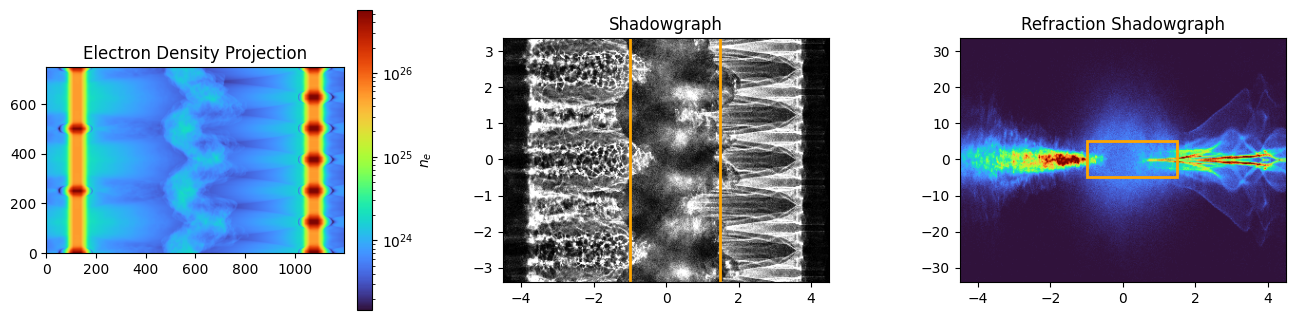

In [21]:
fig = plt.figure(figsize=(16, 6))
outer_grid = fig.add_gridspec(1, 3, height_ratios = [1], width_ratios=[0.5, 0.5, 0.5], wspace=0.4)

# Subplots
ax0 = fig.add_subplot(outer_grid[0, 0])
ax1 = fig.add_subplot(outer_grid[0, 1])
ax2 = fig.add_subplot(outer_grid[0, 2])

# Electron density map
ne_proj = np.trapezoid(domain.ne[:,:,:], dx=0.5/dims[2], axis=2)
im0 = ax0.imshow(
    ne_proj.T,
    origin="lower",
    cmap="turbo",
    norm=LogNorm()
)
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label=r"$n_e$")

# Shadowgraphs
shadow_sh.plot_mm(ax1, cmap="Greys_r", aspect=scale_sh_y/scale_sh_x, clim = [0, 100])
refrac_sh.plot_mm(ax2, cmap="turbo",  aspect = scale_phi/scale_sh_x, clim = [refrac_sh.im.min(), refrac_sh.im.max()*0.7])

# Titles (optional)
ax0.set_title("Electron Density Projection")
ax1.set_title("Shadowgraph")
ax2.set_title("Refraction Shadowgraph")

for ax in [ax1, ax2]:
    rect = patches.Rectangle((-1, -5), 2.5, 10, linewidth=2, edgecolor='orange', facecolor='none')
    # Add the patch to the Axes
    ax.add_patch(rect)

### Comparison with Legacy code

In [11]:
import legacy.full_solver as fs
import legacy.rtm_solver as rtm

In [12]:
# define beam parameters
lwl            =  1064e-9
beam_size      =  [extent_x, extent_y]    # beam radius
probing_extent =  extent_z
ne_extent      =  probing_extent  # so the beam knows where to initialise initial positions
divergence     =  0.1e-3
beam_type      =  "rectangular"

Np = int(1e6)

field = fs.ScalarDomain(ne_x, ne_y, ne_z, ne_extent)
field.external_ne(ne.v*1e6) # m^-3
field.calc_dndr(lwl)

## Initialise rays and solve
s0 = fs.init_beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

field.solve(s0)
rf = field.rf

Starting ray trace.
Ray trace completed in:	 1705.8530271053314 s


In [29]:
import processing.diagnostics as diag

shadowgrapher = diag.Shadowgraphy(rf, focal_plane = 0, prefilter_input = True)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 10, clear_mem = True)

refractometer = diag.Refractometry(rf, focal_plane = 0, prefilter_input = True)
refractometer.incoherent_solve()
refractometer.histogram(bin_scale = 10, clear_mem = True)


1000000 rays received, 878470 retained after optional prefilter.
 --> 12.200000000000001 % filtered before diagnostic solve.

rf size expected: [878470. 878470.]
rf after clearing nan's: [878469. 878469.]

1000000 rays received, 878470 retained after optional prefilter.
 --> 12.200000000000001 % filtered before diagnostic solve.

rf size expected: [878470. 878470.]
rf after clearing nan's: [878469. 878469.]


In [30]:
scale_sh_x   =  shadowgrapher.H.shape[1]/9
scale_sh_y   =  shadowgrapher.H.shape[0]/6.75

L = 400 # distance from the volume to the lens (for a single lens system - 300 mm)

pixel_size  = (13.5/refractometer.H.shape[0])  # pixel size, mm/px in this case because bin = 10, pixel size = 52 um instead 5.4 um
scale_phi   =   1/(2 * pixel_size/L * 1000)  #sensitivity is Lϕ/2, ϕ in radians, convert to mradians.

shadow_sh  =     Image(shadowgrapher.H, 0, scale_sh_x, scale_sh_y, fliplr = True)
o_sh       =     (int(shadowgrapher.H.shape[1]/2), int(shadowgrapher.H.shape[0]/2))
shadow_sh.set_origin(o_sh)

refrac_sh  =     Image(refractometer.H, 0, scale_sh_x, scale_phi, fliplr = True)
o_rh       =     (int(refractometer.H.shape[1]/2), int(refractometer.H.shape[0]/2))
refrac_sh.set_origin(o_rh)

Text(0.5, 1.0, 'Refraction Shadowgraph')

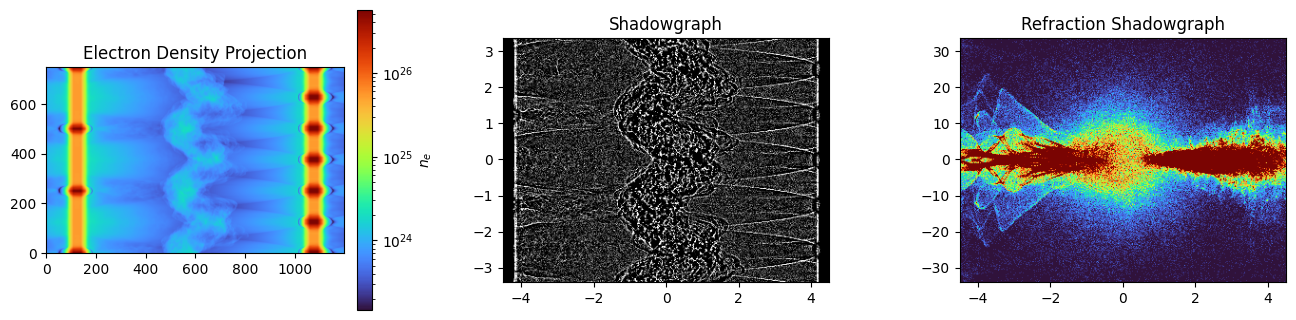

In [41]:
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(16, 6))
outer_grid = fig.add_gridspec(1, 3, height_ratios = [1], width_ratios=[0.5, 0.5, 0.5], wspace=0.4)

# Subplots
ax0 = fig.add_subplot(outer_grid[0, 0])
ax1 = fig.add_subplot(outer_grid[0, 1])
ax2 = fig.add_subplot(outer_grid[0, 2])

# Electron density map
ne_proj = np.trapezoid(domain.ne[:,:,:], dx=0.5/dims[2], axis=2)
im0 = ax0.imshow(
    ne_proj.T,
    origin="lower",
    cmap="turbo",
    norm=LogNorm()
)
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04, label=r"$n_e$")

# Shadowgraphs
shadow_sh.plot_mm(ax1, cmap="Greys_r", aspect=scale_sh_y/scale_sh_x, clim = [5, 25])
refrac_sh.plot_mm(ax2, cmap="turbo", aspect = scale_phi/scale_sh_x, clim = [0, 30])

# Titles (optional)
ax0.set_title("Electron Density Projection")
ax1.set_title("Shadowgraph")
ax2.set_title("Refraction Shadowgraph")

Text(0, 0.5, '$\\phi$ (mrad)')

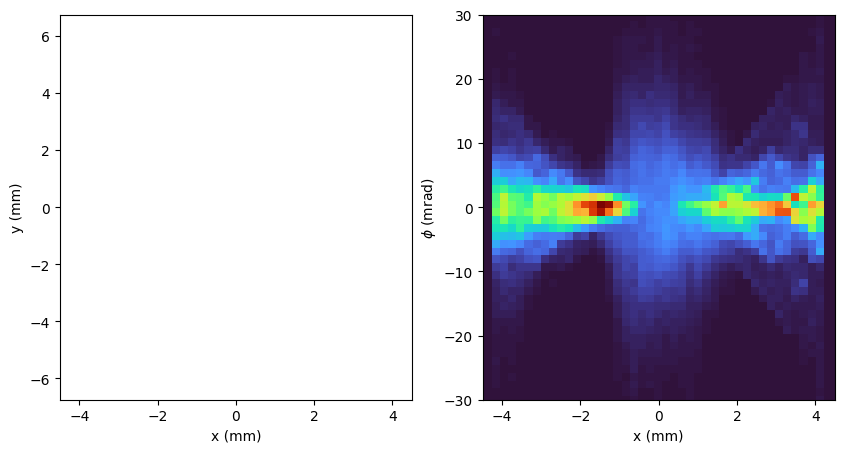

In [15]:
import matplotlib.colors as mcolors

nbins_x=3448
nbins_y=2574

# ----------------------

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,5))

_,_,_,img1 = ax2.hist2d(rf[0]*1e3, rf[2]*1e3, bins=(nbins_x, nbins_y), cmap ="turbo");

ax1.set_ylim([-6.75, 6.75])
ax1.set_xlim(-4.5, 4.5)
ax1.set_xticks([-4, -2, 0, 2, 4])
ax1.set_aspect('auto')

ax1.set_xlabel(r"x (mm)")
ax1.grid(False)
ax1.set_ylabel(r"y (mm)")

_,_,_,img1 = ax2.hist2d(rf[0]*1e3, rf[3]*1e3, bins=(nbins_x, nbins_y), norm=mcolors.PowerNorm(1), cmap ="turbo");

ax2.set_xlim(-4.5, 4.5)
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_aspect('auto')

ax2.set_xlabel(r"x (mm)")
ax2.set_ylim(-30,30)
ax2.set_yticks([-30, -20,-10,0,10,20,30])
ax2.grid(False)
ax2.set_ylabel(r"$\phi$ (mrad)")

np.float64(-1.5611996208863324)